In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects

In [2]:
alphas_S1 = [0.1, 0.2, 0.3, 0.4]
gammas_S1 = [0.8, 0.9, 0.95, 0.99]

In [3]:
maxcost_S1 = pd.read_csv(f'round1/alpha01_gamma80/results/evaluation.csv')['Stage 0'].median()

In [4]:
best_cost_S1 = []
for a in alphas_S1:
    best_cost_S1.append([])
    for g in gammas_S1:
        astr = str(a).replace('.', '')
        gstr = str(g)[2:].ljust(2, '0')
        C = pd.read_csv(f'round1/alpha{astr}_gamma{gstr}/results/evaluation.csv').median().min()
        best_cost_S1[-1].append(((maxcost_S1 - C) / maxcost_S1) * 100)

In [5]:
arr = np.array(best_cost_S1)
a_idx, g_idx = np.unravel_index(arr.argmax(), arr.shape)

best_a = alphas_S1[a_idx]
best_g = gammas_S1[g_idx]
best_a, best_g

(0.1, 0.9)

In [8]:
alphas_S2 = [0.04, 0.08, 0.12, 0.16]
gammas_S2 = [0.85, 0.89, 0.92, 0.94]

In [7]:
maxcost_S2 = pd.read_csv(f'round2/alpha040_gamma81/results/evaluation.csv')['Stage 0'].median()

In [8]:
best_cost_S2 = []
for a in alphas_S2:
    best_cost_S2.append([])
    for g in gammas_S2:
        astr = str(a).replace('.', '').ljust(3, '0')
        gstr = str(g).replace('.', '').replace('0', '')
        C = pd.read_csv(f'round2/alpha{astr}_gamma{gstr}/results/evaluation.csv').median().min()
        best_cost_S2[-1].append(((maxcost_S2 - C) / maxcost_S2) * 100)

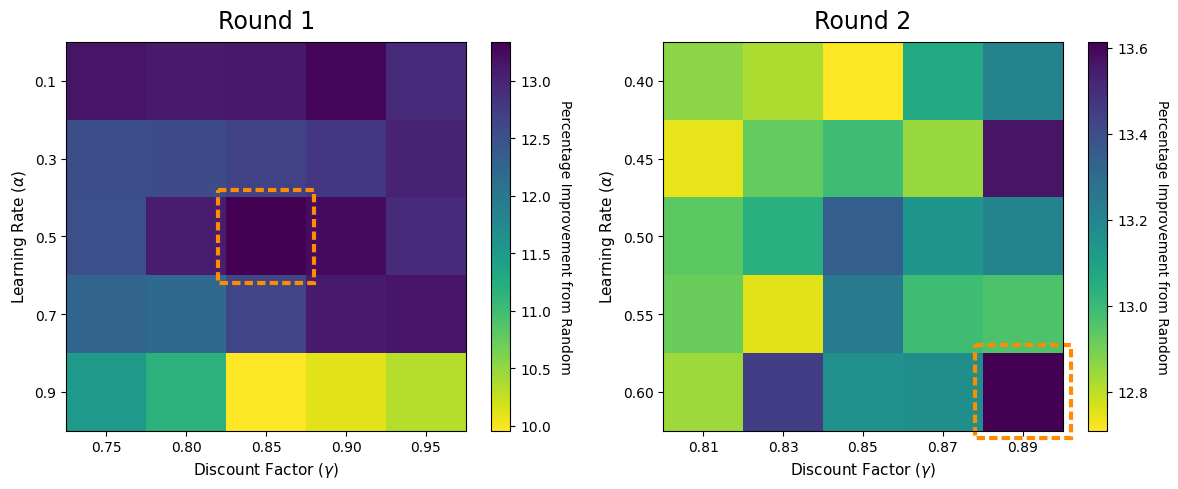

In [9]:
fig, axarr = plt.subplots(1, 2, figsize=(12, 5))

im = axarr[0].imshow(best_cost_S1, cmap="viridis_r", aspect="auto")
cbar = fig.colorbar(im, ax=axarr[0])
cbar.set_label("Percentage Improvement from Random", rotation=270, labelpad=15)
axarr[0].set_xticks(np.arange(len(gammas_S1)))
axarr[0].set_yticks(np.arange(len(alphas_S1)))
axarr[0].set_xticklabels([f"{g:.2f}" for g in gammas_S1])
axarr[0].set_yticklabels([f"{a:.1f}" for a in alphas_S1])
axarr[0].set_xlabel(r"Discount Factor ($\gamma$)", fontsize=11)
axarr[0].set_ylabel(r"Learning Rate ($\alpha$)", fontsize=11)
axarr[0].set_title("Round 1", fontsize=17, pad=10)

rect = patches.Rectangle(
    (1.4, 1.4),  # (x_min, y_min) in grid coordinates
    1.2,  # width (0.75 -> 0.85)
    1.2,  # height (0.10 -> 0.30)
    linewidth=3,
    edgecolor="darkorange",
    facecolor="none",
    linestyle=(0, (2, 1)),
    clip_on=False
)
axarr[0].add_patch(rect)


im = axarr[1].imshow(best_cost_S2, cmap="viridis_r", aspect="auto")
cbar = fig.colorbar(im, ax=axarr[1])
cbar.set_label("Percentage Improvement from Random", rotation=270, labelpad=15)
axarr[1].set_xticks(np.arange(len(gammas_S2)))
axarr[1].set_yticks(np.arange(len(alphas_S2)))
axarr[1].set_xticklabels([f"{g:.2f}" for g in gammas_S2])
axarr[1].set_yticklabels([f"{a:.2f}" for a in alphas_S2])
axarr[1].set_xlabel(r"Discount Factor ($\gamma$)", fontsize=11)
axarr[1].set_ylabel(r"Learning Rate ($\alpha$)", fontsize=11)
axarr[1].set_title("Round 2", fontsize=17, pad=10)

rect = patches.Rectangle(
    (3.4, 3.4),  # (x_min, y_min) in grid coordinates
    1.2,  # width (0.75 -> 0.85)
    1.2,  # height (0.10 -> 0.30)
    linewidth=3,
    edgecolor="darkorange",
    facecolor="none",
    linestyle=(0, (2, 1)),
    clip_on=False
)
axarr[1].add_patch(rect)

plt.tight_layout()
fig.savefig("../../../plt/param_sweep.pdf")